In this notebook, we will compute the local antibody brightness for each relevant immunofluorescence rounds.

Relevant figures can be found in Figure 2, Extended Data Figure 3

In [1]:
import os
import numpy as np
import pandas as pd
import sys

In [2]:
sys.path.append('../scripts/')
from ioMicroS6A import *
from ecDNATracer_antibody import *
from plot import *

# compute local antibody brightness

In [7]:
dic_iA_flds = {1: 'A1_H3K9me3_Pol2S2_set1', 2:'A1_H3K9me3_Pol2S2_set1',
              4: 'A2_SC35_H3K27Ac_set1', 5: 'A2_SC35_H3K27Ac_set1',
              7: 'A3_Lam_Nup98-high_set1',8:'A3_Lam_Nup98-high_set1'}
dic_iA_Around = {1:'A1_R1_2_3',2:'A1_R1_2_3',
                4: 'A2_R4_5_6', 5: 'A2_R4_5_6',
                7: 'A3_Lam_Nup98-high', 8: 'A3_Lam_Nup98-high'}
dic_iA_antibody = {1: 'H3K9me3', 2: 'Pol2S2',
                   4: 'SC35', 5: 'H3K27Ac',
                  7: 'LAMA1', 8: 'NUP98'}

dic_iA_antibody_fullname = {1: 'H3K9me3', 2: 'p-RNA polymerase II', 4: 'Spliceosome', 5: 'H3K27Ac', 7: 'Lamina A/C', 8: 'NUP98'}

pix_size = [0.4, 0.108333, 0.108333]

## compute local antibody brightness

In [34]:
df_summary_full = pd.read_csv('C:/GBM39/invirto_030125/121225__df-global_transcription-rgs-antibody_H__invitro_030125.csv',
                index_col = 0)

In [35]:
df_summary_full['ifov'] = df_summary_full['cell_id'].astype(int) // 10**5
uifovs_full = np.unique(np.array(df_summary_full['cell_id']) // 10**5)
len(uifovs_full)

31

In [21]:
import pickle
with open(r'D:\GBM39\ecDNATracer\gridSearch_traces_chromabb___invitro_03012025\BT__preEM_strict_redooffby1_31FOVs__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)
tr_type = 'Xtraces_chrom_inter_73_253_254'
linear_traces, circ_traces = dic_linear_circ_by_type[tr_type]
linear_traces.shape, circ_traces.shape

((849, 252, 6), (35969, 252, 6))

In [22]:
pool_to_traces = {"linear": linear_traces, "circular": circ_traces}

def drift_globber_cellculture(iA):
    if iA in [1, 2, 4, 5]:
        return glob.glob(os.path.join(
            r"Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__polII_analysis", "drift*"
        ))
    else:
        return glob.glob(os.path.join(
            r"Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__lamina_analysis", "*drift*"
        ))

def fld_from_iA_cellculture(iA):
    return rf"\\132.239.200.19\banana1\dragonfruit1\CellCulture_EGFR_03_01_2025\{dic_iA_flds[iA]}"


In [45]:
## run it for all fovs
df_ab_full = df_summary_full.copy()
df_ab_full = df_ab_full.drop(columns = ['iA2_ab_norm_robust_H','iA4_ab_norm_robust_H','iA5_ab_norm_robust_H'])
for iA in [2,5,7]:
# for iA in [2]:
    df_plot_full = get_antibody_norm_brightness_zscore_streaming(
        iA=iA,
        df_meta=df_ab_full,
        ufovs=uifovs_full,
        use_robust_std=True,
        batch_size_fovs=1,
        fov_from_ifov=lambda ifov: f"Conv_zscan1__{str(int(ifov)).zfill(3)}",
        drift_globber=drift_globber_cellculture,
        fld_from_iA=fld_from_iA_cellculture,
        flat_field_tag=r"\\132.239.200.19\banana1\RenImaging2\Brett\CellCulture_EGFR_03_01_2025\flat_field",
        pool_to_traces=pool_to_traces,
        pix_size=pix_size,
    )

 10%|████████                                                                           | 3/31 [00:24<03:52,  8.29s/it]C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_5512\3056736661.py:77: RuntimeWarning: Mean of empty slice
  mean_brightness = np.nanmean(intensities, axis=1).astype(np.float32)
 16%|█████████████▍                                                                     | 5/31 [00:41<03:44,  8.62s/it]C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_5512\3056736661.py:77: RuntimeWarning: Mean of empty slice
  mean_brightness = np.nanmean(intensities, axis=1).astype(np.float32)
 71%|██████████████████████████████████████████████████████████▏                       | 22/31 [03:16<01:21,  9.06s/it]C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_5512\3056736661.py:77: RuntimeWarning: Mean of empty slice
  mean_brightness = np.nanmean(intensities, axis=1).astype(np.float32)
 10%|████████                                                                           | 3/31 [00:27<04:1

In [46]:
df_plot_full[(df_plot_full['cell_id'] == 2000004) & (df_plot_full['global_row'] == 12)]

,cell_id,pool,trace_id,global_row,EGFR,EGFR-AS1,LANCL2,FKBP9P1,SEPTIN14,ZNF713,...,matrix_name,centroid,dist_to_com,dist_to_lamina,inside_nucleus,rgs,ifov,iA2_ab_norm_robust_H,iA5_ab_norm_robust_H,iA7_ab_norm_robust_H
14,2000004,circular,12,12,0,1,1,0,0,0,...,circular,"(4.333360772974353, 194.72745666357434, 44.500...",9.221877,0.676643,True,0.340262,20,0.723715,-2.030993,2.903324


## plot 3 way correlation

In [48]:
## split to ecDNA only
df_summary_circ = df_plot_full[df_plot_full['pool'] == 'circular']
df_summary_circ.shape

(34349, 28)

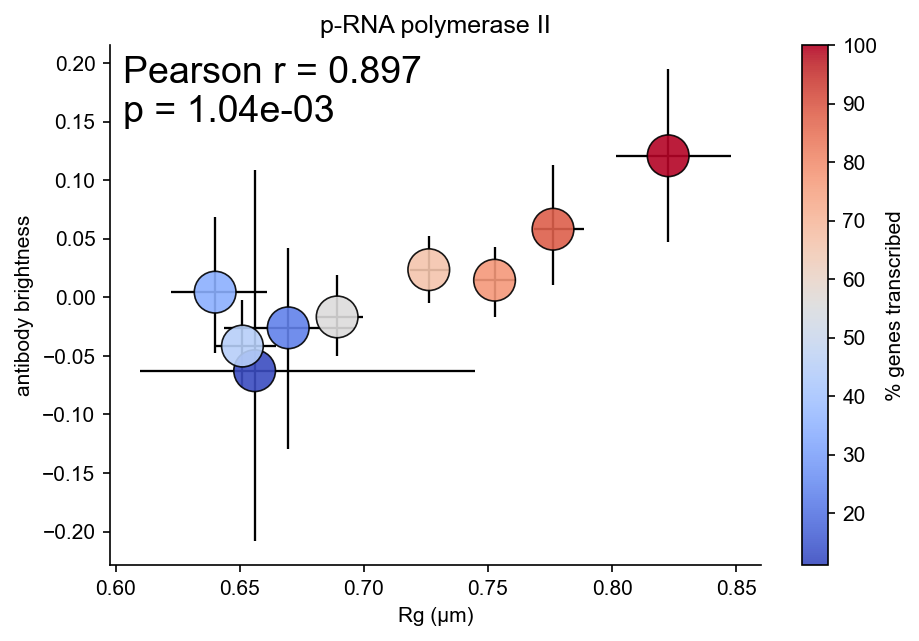

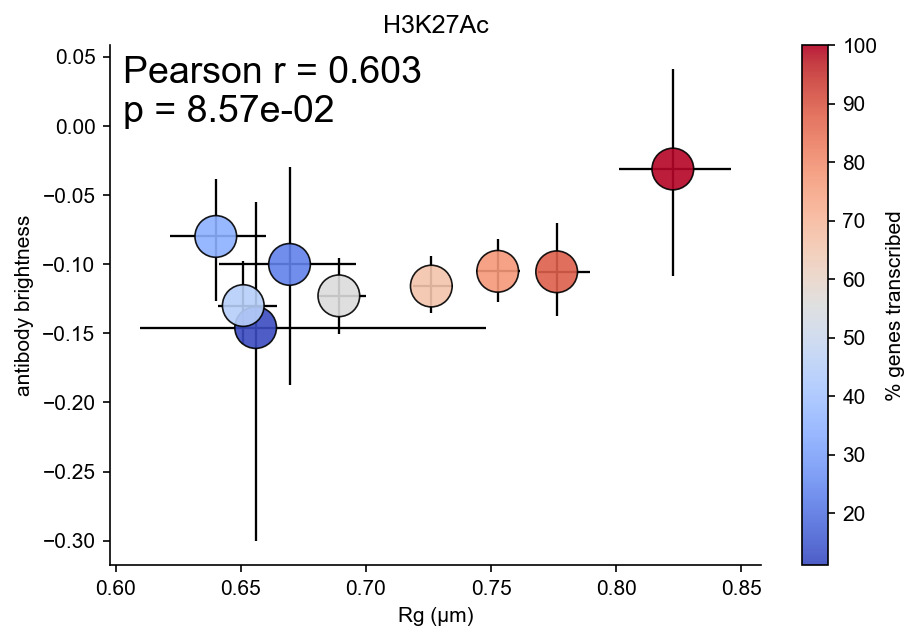

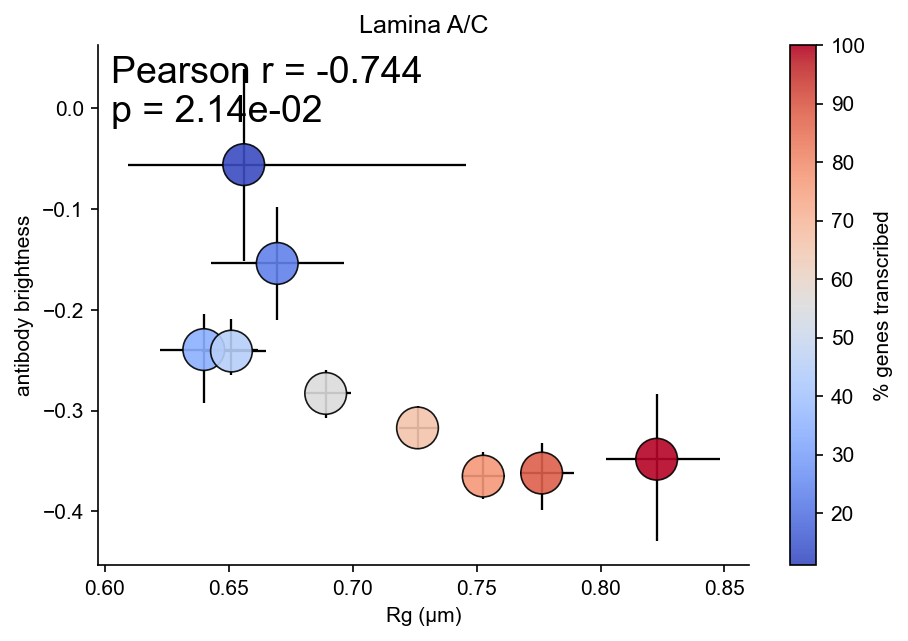

In [49]:
## plot each one of them and save
for iA in [2,5,7]:
    dotplot_bootstrap_median_with_pearson(
            df_summary_circ,
            cmap="coolwarm",  # blue->red
            figsize=(7,4.5),
            s=400,
            x_col = 'rgs',
            y_col =  f"iA{iA}_ab_norm_robust_H",
            z_col = 'total_genes_transcribed',
            x_label="Rg (µm)",
            y_label= 'antibody brightness',
            z_label = '% genes transcribed',
            title = dic_iA_antibody_fullname[iA],
            # save_svg = None,
            group_col = 'total_genes_transcribed',
            n_groups = None,
            ax = None,
            z_to_percent=True,
            # save_svg= f"C:/GBM39/manuscript_figures/invitro_fig2/plots/antibody_brightness_updated/ecDNA_antibody_iA{iA}_{dic_iA_antibody[iA]}__rgs_H_dotplot_nonumber_withPearson.svg"
        )


# global antibody

This computes the average brightness across an entire cell to see if a cell has a globally higher transcriptional state

## import functions

In [50]:
def flat_field_image_global(
    fov,
    iA,
    fld = None,
    flat_field_tag = r'\\132.239.200.19\banana1\RenImaging2\Brett\CellCulture_EGFR_03_01_2025\flat_field' + os.sep,
    use_robust_std=False,
    precomputed_scale=None,
):
    """
    Flat-field correct and normalize an image.

    Parameters
    ----------
    fov : str
        Filename of the raw image (whatever read_im expects).
    iA : int
        Channel index (1-based) used to pick the color: (iA-1) % 3.
    fld : str
        Folder containing the raw image.
    flat_field_tag : str
        Prefix/path for flat-field files, e.g. 'C:/.../flatfield_'.
        Will load: flat_field_tag + 'med_col_raw{icol}.npz'
    use_robust_std : bool, optional
        If True, use MAD-based robust std instead of np.std.
    precomputed_scale : float or None
        If provided, skip computing std/MAD and just divide by this.

    Returns
    -------
    im_norm : np.ndarray, float32
        Flat-field corrected and normalized image, same shape as im__.
    """
    if fld is None:
        fld = rf'\\132.239.200.19\banana1\dragonfruit1\CellCulture_EGFR_03_01_2025\{dic_iA_flds[iA]}'
    icol = (iA - 1) % 3

    # --- load & flat-field correct ---
    im_ = read_im(os.path.join(fld, fov))      # shape: (C, H, W) or similar
    im__ = np.array(im_[icol], dtype=np.float32)  

    fl_med = f"{flat_field_tag}med_col_raw{icol}.npz"
    im_med = np.array(np.load(fl_med)["im"], dtype=np.float32)
    im_med = cv2.blur(im_med, (20, 20)) # (20, 20)

    # flat-field correction: bring illumination to median of im_med
    im__ = im__ / im_med * np.median(im_med)

    im_norm = (im__ - np.median(im__)) / np.std(im__)

    return im_norm.astype(np.float32)

In [51]:
import numpy as np
import pandas as pd


def _block_reduce_mean_zxy(img_zxy: np.ndarray, resc=(2, 4, 4)) -> np.ndarray:
    """Downsample (Z,X,Y) by integer factors resc=(rz,rx,ry) using block-mean."""
    if img_zxy.ndim != 3:
        raise ValueError(f"Expected 3D (Z,X,Y), got {img_zxy.shape}")

    rz, rx, ry = map(int, resc)
    Z, X, Y = img_zxy.shape
    Zc = (Z // rz) * rz
    Xc = (X // rx) * rx
    Yc = (Y // ry) * ry
    if (Zc, Xc, Yc) != (Z, X, Y):
        img_zxy = img_zxy[:Zc, :Xc, :Yc]

    Z2, X2, Y2 = Zc // rz, Xc // rx, Yc // ry
    return img_zxy.reshape(Z2, rz, X2, rx, Y2, ry).mean(axis=(1, 3, 5))


def _sample_trilinear_constant0(img: np.ndarray, coords: np.ndarray) -> np.ndarray:
    """
    Trilinear sample img(Z,X,Y) at float coords (N,3) in ZXY order.
    Out-of-bounds -> 0.
    """
    Z, X, Y = img.shape
    z = coords[:, 0]
    x = coords[:, 1]
    y = coords[:, 2]

    z0 = np.floor(z).astype(np.int64)
    x0 = np.floor(x).astype(np.int64)
    y0 = np.floor(y).astype(np.int64)

    z1 = z0 + 1
    x1 = x0 + 1
    y1 = y0 + 1

    wz = (z - z0).astype(np.float32)
    wx = (x - x0).astype(np.float32)
    wy = (y - y0).astype(np.float32)

    def get(zz, xx, yy):
        ok = (zz >= 0) & (zz < Z) & (xx >= 0) & (xx < X) & (yy >= 0) & (yy < Y)
        out = np.zeros(zz.shape[0], dtype=np.float32)
        if np.any(ok):
            out[ok] = img[zz[ok], xx[ok], yy[ok]].astype(np.float32, copy=False)
        return out

    c000 = get(z0, x0, y0)
    c001 = get(z0, x0, y1)
    c010 = get(z0, x1, y0)
    c011 = get(z0, x1, y1)
    c100 = get(z1, x0, y0)
    c101 = get(z1, x0, y1)
    c110 = get(z1, x1, y0)
    c111 = get(z1, x1, y1)

    # interpolate
    c00 = c000 * (1 - wy) + c001 * wy
    c01 = c010 * (1 - wy) + c011 * wy
    c10 = c100 * (1 - wy) + c101 * wy
    c11 = c110 * (1 - wy) + c111 * wy

    c0 = c00 * (1 - wx) + c01 * wx
    c1 = c10 * (1 - wx) + c11 * wx

    return c0 * (1 - wz) + c1 * wz


def compute_global_cell_mean_from_dapi_segm_with_drift(
    *,
    fov,
    iA,
    cell_ids,
    dapi_segm_zxy_ds,
    drft_zxy,
    # flat_field_image_global,
    resc=(2, 4, 4),
    segm_values_are_cell_ids=True,
    reducer="mean",          # "mean" or "median"
    min_pixels=1,
    return_pixel_counts=False,
):
    """
    Per-FOV:
      1) norm_im = flat_field_image_global(fov, iA)  -> raw-res (Z,X,Y)
      2) downsample norm_im by resc=(2,4,4) to match dapi_segm grid
      3) apply drift correction between segm (reference frame) and norm_im

    IMPORTANT about drift direction:
    - You said: in napari you do `add_image(norm_im, translate=drft)` to place norm_im
      into the reference frame. That means norm_im's coordinates are shifted by +drft
      when displayed.
    - Therefore, to sample intensity at a reference-frame coordinate r (segm pixel),
      we need to sample from norm_im at r - drft.
      (Because pixel at r in reference corresponds to pixel r - drft in the unshifted image.)

    We do this by sampling norm_im_downsampled at (ref_coords - drft_ds).
    Sampling is trilinear with out-of-bounds=0.

    Returns
    -------
    df with columns:
      - 'cell_id'
      - f'iA{iA}_global_cell_mean'
      - optionally f'iA{iA}_global_cell_npix'
    """
    cell_ids = np.asarray(cell_ids)
    if cell_ids.ndim != 1:
        raise ValueError("cell_ids must be 1D")

    segm = np.asarray(dapi_segm_zxy_ds)
    if segm.ndim != 3:
        raise ValueError(f"dapi_segm_zxy_ds must be 3D (Z,X,Y), got {segm.shape}")

    drft = np.asarray(drft_zxy, dtype=np.float32).reshape(3,)
    rz, rx, ry = map(float, resc)

    # 1) normalized image (raw-res)
    norm_im = flat_field_image_global(fov, iA)
    norm_im = np.asarray(norm_im, dtype=np.float32)
    if norm_im.ndim != 3:
        raise ValueError(f"flat_field_image_global(fov,iA) must return 3D (Z,X,Y), got {norm_im.shape}")

    # 2) downsample to segm grid
    img_ds = _block_reduce_mean_zxy(norm_im, resc=resc)
    if img_ds.shape != segm.shape:
        raise ValueError(
            f"After downsampling with resc={resc}, image shape {img_ds.shape} "
            f"does not match segm shape {segm.shape}."
        )

    # 3) convert drift from raw-res pixels to segm-res pixels
    # raw pixel shift drft -> downsampled pixel shift drft_ds
    drft_ds = np.array([drft[0] / rz, drft[1] / rx, drft[2] / ry], dtype=np.float32)

    # We'll evaluate intensity at segm pixels by sampling img_ds at (coords - drft_ds)
    segm_flat = segm.astype(np.int32, copy=False).ravel()

    if reducer not in ("mean", "median"):
        raise ValueError("reducer must be 'mean' or 'median'")

    out_vals = np.full(cell_ids.shape[0], np.nan, dtype=np.float32)
    out_npix = np.zeros(cell_ids.shape[0], dtype=np.int64)

    # Precompute coordinates for all voxels once (fast enough per-FOV; avoids per-cell meshgrid)
    Zs, Xs, Ys = segm.shape
    zz, xx, yy = np.indices((Zs, Xs, Ys), dtype=np.float32)
    coords_ref = np.stack([zz.ravel(), xx.ravel(), yy.ravel()], axis=1)  # (N,3) in ZXY
    coords_img = coords_ref - drft_ds[None, :]                           # sample locations in img_ds
    intens_all = _sample_trilinear_constant0(img_ds, coords_img)          # (N,)

    if segm_values_are_cell_ids:
        for j, cid in enumerate(cell_ids):
            m = (segm_flat == int(cid))
            n = int(m.sum())
            out_npix[j] = n
            if n < min_pixels:
                continue
            vals = intens_all[m]
            out_vals[j] = float(np.nanmean(vals) if reducer == "mean" else np.nanmedian(vals))
    else:
        # labels 1..N correspond to cell_ids by order (label k+1 -> cell_ids[k])
        labels = segm_flat
        valid = labels > 0
        labels_v = labels[valid]
        vals_v = intens_all[valid]

        if reducer == "mean":
            maxlab = int(labels_v.max()) if labels_v.size else 0
            sums = np.bincount(labels_v, weights=vals_v, minlength=maxlab + 1)
            cnts = np.bincount(labels_v, minlength=maxlab + 1)
            for k in range(cell_ids.size):
                lab = k + 1
                if lab <= maxlab:
                    out_npix[k] = int(cnts[lab])
                    if cnts[lab] >= min_pixels:
                        out_vals[k] = float(sums[lab] / cnts[lab])
        else:
            for k in range(cell_ids.size):
                lab = k + 1
                m = (labels == lab)
                n = int(m.sum())
                out_npix[k] = n
                if n < min_pixels:
                    continue
                out_vals[k] = float(np.nanmedian(intens_all[m]))

    col_mean = f"iA{iA}_global_cell_mean"
    
    ## store ifovcell
    ifov = int(fov.split('_')[-1])
    ifovcells = 10**5 * ifov + cell_ids
    df = pd.DataFrame({"cell_id": ifovcells, col_mean: out_vals})
    if return_pixel_counts:
        df[f"iA{iA}_global_cell_npix"] = out_npix
    return df


## compute global brightness

In [54]:
df_ecDNA_mean = df_summary_circ.groupby('cell_id').mean().reset_index()

C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_5512\2430250278.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_ecDNA_mean = df_summary_circ.groupby('cell_id').mean().reset_index()


In [57]:
df_ecDNA_mean['ifov'] = df_ecDNA_mean['cell_id'] // 10**5
df_ecDNA_mean['icell'] = df_ecDNA_mean['cell_id'] % 10**5

In [ ]:
import os, glob
import numpy as np
import pandas as pd

dfs_long = []

for iA in [2, 5]:

    # choose drift directory once per iA
    if iA in [1, 2, 4, 5]:
        drift_fls = glob.glob(os.path.join(
            r'Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__polII_analysis', 'drift*'
        ))
    else:
        drift_fls = glob.glob(os.path.join(
            r'Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__lamina_analysis', '*drift*'
        ))

    for ifov in tqdm(uifovs_full):
        fov = f'Conv_zscan1__{int(ifov):03d}'

        ## load dapi segm
        dapi_segm_ifov = np.load(
            rf'Y:\dragonfruit1\CellCulture_EGFR_03_01_2025__merged_Segmentation\{fov}--Q11_MER_set1--dapi-cyto_segm.npz'
        )['dapi_segm']

        dic_drifts = get_dic_drifts(fov, drift_fls=drift_fls)

        cell_ids = df_ecDNA_mean.loc[
            df_ecDNA_mean['ifov'] == ifov, 'icell'
        ].to_numpy()

        df_tmp = compute_global_cell_mean_from_dapi_segm_with_drift(
            fov=fov,
            iA=iA,
            cell_ids=cell_ids,
            dapi_segm_zxy_ds=dapi_segm_ifov,
            drft_zxy=dic_drifts[dic_iA_Around[iA]],
            return_pixel_counts= True
        )

        # rename mean column → generic name
        mean_col = f"iA{iA}_global_cell_mean"
        df_tmp = df_tmp.rename(columns={mean_col: "mean_val"})

        df_tmp["iA"] = iA
        df_tmp["ifov"] = ifov

        dfs_long.append(df_tmp)

df_long = pd.concat(dfs_long, ignore_index=True)


 29%|████████████████████████                                                           | 9/31 [01:29<03:40, 10.02s/it]

In [ ]:
## convert to wide style
df_wide = (
    df_long
    .pivot_table(
        index=["ifov", "cell_id"],
        columns="iA",
        values="mean_val"
    )
    .rename(columns=lambda x: f"iA{x}_global_cell_mean")
    .reset_index()
)
df_wide

## plot